# Sprint 10 - Baseline vs actual, latencia y robustez

Este notebook resume evidencia ya generada por `src/run_sprint10_validation_latency.py`.

**Nota metodológica:** el modelo actual excluye `duration_hours_evidence`, porque la duración final no está disponible al inicio y forma parte de la construcción de `label_over_ola`. La percepción del stakeholder se mantiene como pendiente hasta recolectar respuestas reales; no se usan datos sintéticos como evidencia de usuario.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
if not (ROOT / 'results').exists():
    ROOT = ROOT.parent
print('Repositorio:', ROOT.resolve())

Repositorio: .


## 1. Particiones y comparativo técnico

In [2]:
splits = pd.read_csv(ROOT / 'logs/split_summary_sprint10.csv')
metrics = pd.read_csv(ROOT / 'results/baseline_vs_actual_sprint10.csv')
comparison = pd.read_csv(ROOT / 'results/baseline_actual_comparison_sprint10.csv')
display(splits)
display(metrics)
display(comparison)

,split,n,positive_rate,start,end
0,train,7566,0.326196,2024-01-01 05:00:00,2025-09-24 04:00:00
1,calibration,1079,0.285449,2025-09-24 05:00:00,2025-12-08 08:00:00
2,test,2161,0.331328,2025-12-08 11:00:00,2026-04-24 11:00:00


,system,evaluation,threshold,f1,precision,recall,average_precision,balanced_accuracy,brier,tp,fp,fn,tn,weighted_cost_fp_plus_3fn,alert_rate,f1_ci95_low,f1_ci95_high,precision_ci95_low,precision_ci95_high,recall_ci95_low,recall_ci95_high,average_precision_ci95_low,average_precision_ci95_high,brier_ci95_low,brier_ci95_high
0,BAU_rule_frozen_vS7,chronological_holdout,0.500,0.492058,0.329239,0.973464,0.356250,0.495382,0.427525,697,1420,19,25,1477,0.979639,0.469301,0.513411,0.309369,0.348783,0.960730,0.984540,0.330056,0.383075,0.416387,0.439606
1,sprint10-logreg-leakage-safe-v1,chronological_holdout,0.245,0.503040,0.345511,0.924581,0.435166,0.528380,0.221090,662,1254,54,191,1416,0.886627,0.479254,0.527143,0.324401,0.367976,0.905028,0.943756,0.400567,0.471169,0.214992,0.227074


,metric,unit,baseline,actual,absolute_delta_actual_minus_baseline,relative_delta_pct,baseline_ci95_low,baseline_ci95_high,actual_ci95_low,actual_ci95_high
0,F1,ratio,0.492058,0.503040,0.010982,2.231775,0.469301,0.513411,0.479254,0.527143
1,Precisión,ratio,0.329239,0.345511,0.016272,4.942297,0.309369,0.348783,0.324401,0.367976
2,Recall,ratio,0.973464,0.924581,-0.048883,-5.021521,0.960730,0.984540,0.905028,0.943756
3,Average Precision,ratio,0.356250,0.435166,0.078917,22.152103,0.330056,0.383075,0.400567,0.471169
4,Balanced accuracy,ratio,0.495382,0.528380,0.032998,6.661139,NaN,NaN,NaN,NaN
5,Brier (menor es mejor),ratio,0.427525,0.221090,-0.206435,-48.286115,0.416387,0.439606,0.214992,0.227074
6,Costo FP + 3*FN (menor es mejor),casos,1477.000000,1416.000000,-61.000000,-4.129993,NaN,NaN,NaN,NaN
7,Tasa de alertas,ratio,0.979639,0.886627,-0.093012,-9.494568,NaN,NaN,NaN,NaN
8,Falsos positivos,casos,1420.000000,1254.000000,-166.000000,-11.690141,NaN,NaN,NaN,NaN
9,Falsos negativos,casos,19.000000,54.000000,35.000000,184.210526,NaN,NaN,NaN,NaN


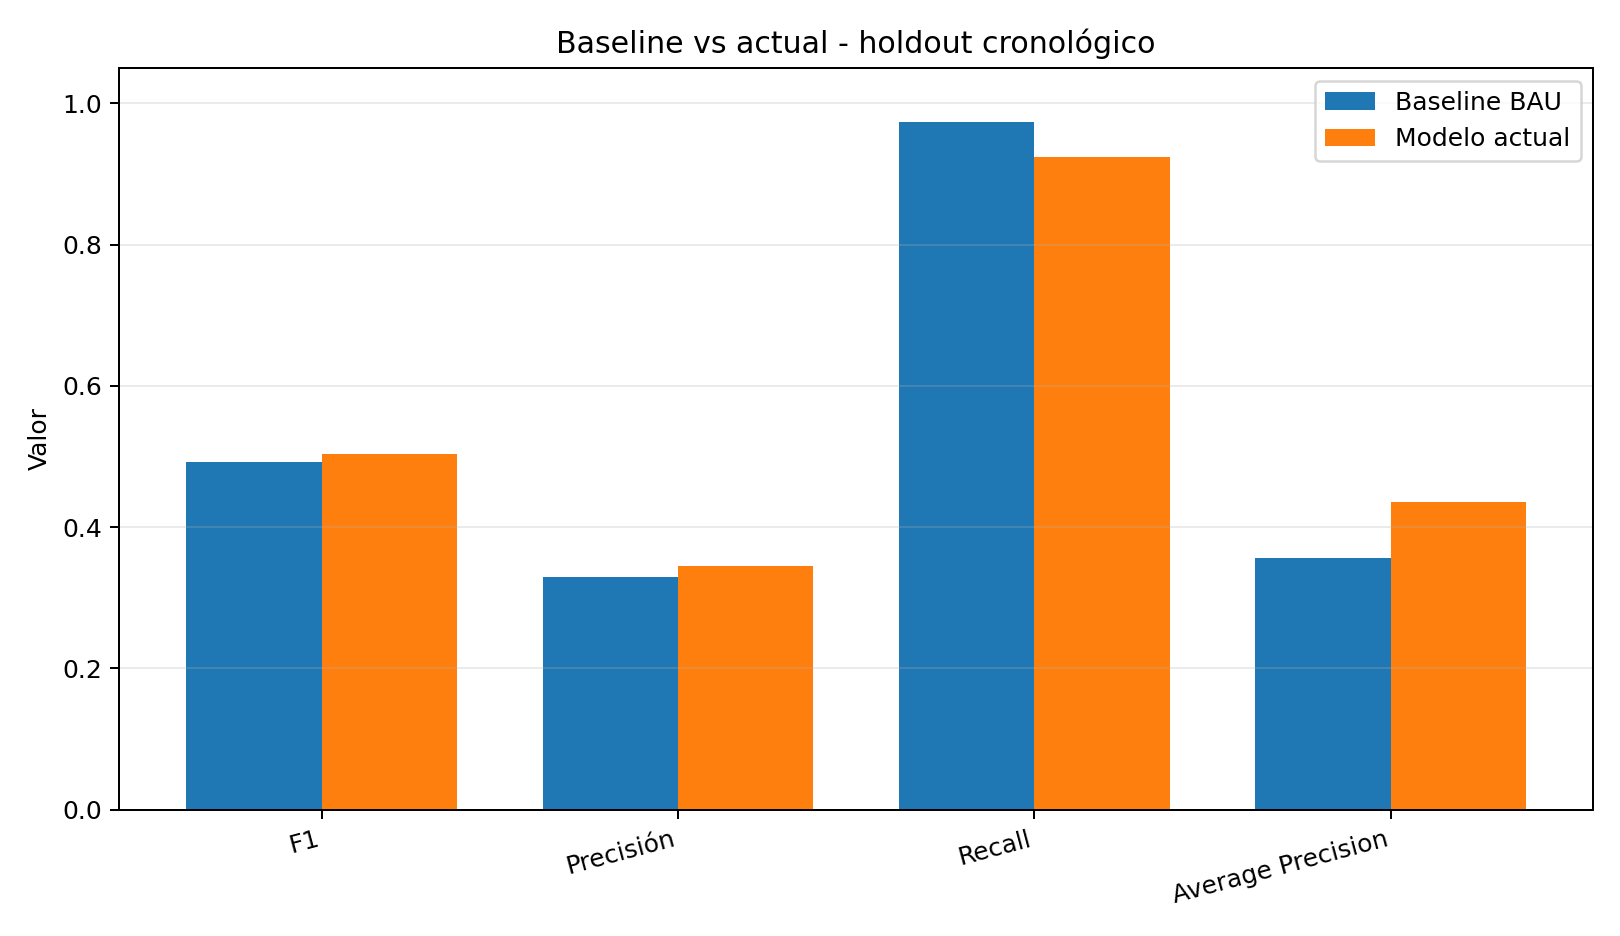

In [3]:
display(Image(filename=str(ROOT / 'results/fig_baseline_vs_actual_sprint10.png')))

## 2. Selección de modelo y umbral

In [4]:
candidates = pd.read_csv(ROOT / 'results/model_candidate_grid_sprint10.csv')
thresholds = pd.read_csv(ROOT / 'results/threshold_sensitivity_calibration_sprint10.csv')
display(candidates)
print('Umbral congelado del modelo seleccionado:', metrics.loc[metrics.system.str.contains('sprint10'), 'threshold'].iloc[0])

,candidate,C,class_weight,fit_sec,threshold,f1,precision,recall,average_precision,balanced_accuracy,brier,tp,fp,fn,tn,weighted_cost_fp_plus_3fn,alert_rate
0,LogReg_C3.0_cw_balanced,3.0,balanced,0.100942,0.405,0.504798,0.358311,0.853896,0.455656,0.621501,0.225509,263,471,45,300,606,0.680259
1,LogReg_C1.0_cw_balanced,1.0,balanced,0.101377,0.405,0.504314,0.357823,0.853896,0.457437,0.620852,0.224876,263,472,45,299,607,0.681186
2,LogReg_C3.0_cw_none,3.0,none,0.111695,0.245,0.501435,0.355495,0.850649,0.457398,0.617283,0.188945,262,475,46,296,613,0.683040
3,LogReg_C1.0_cw_none,1.0,none,0.091372,0.245,0.500956,0.355014,0.850649,0.458348,0.616635,0.188590,262,476,46,295,614,0.683967
4,LogReg_C0.1_cw_balanced,0.1,balanced,0.093402,0.395,0.500952,0.354447,0.853896,0.467887,0.616313,0.220768,263,479,45,292,614,0.687674
5,LogReg_C0.1_cw_none,0.1,none,0.083604,0.235,0.497653,0.350066,0.860390,0.468122,0.611129,0.186711,265,492,43,279,621,0.701576


Umbral congelado del modelo seleccionado: 0.2449999999999998


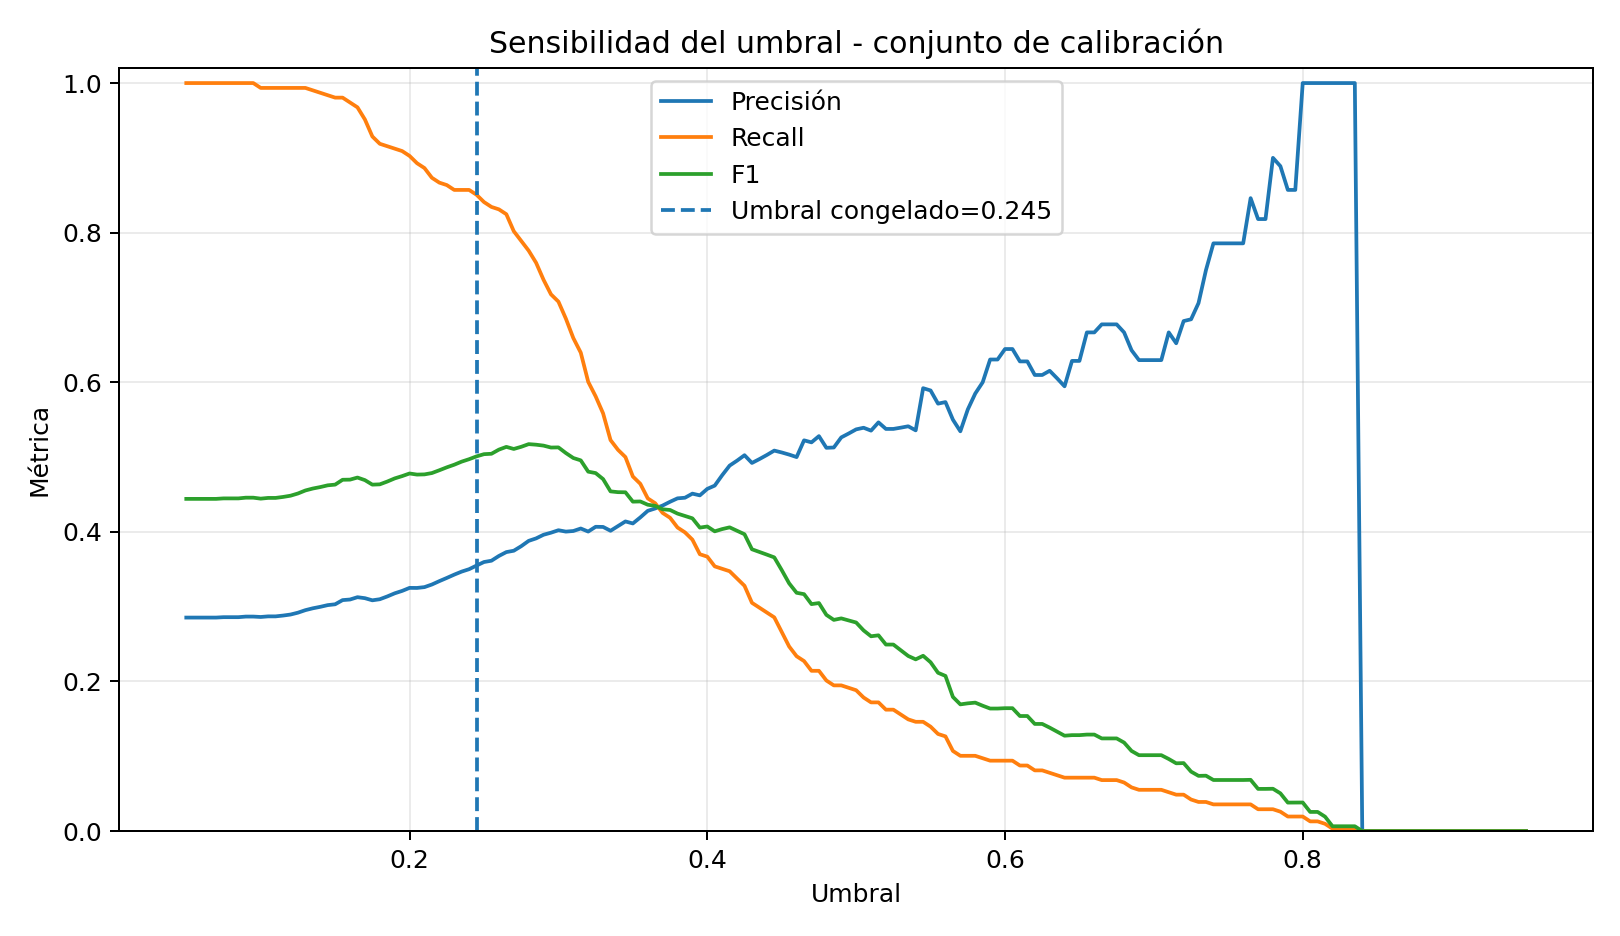

In [5]:
display(Image(filename=str(ROOT / 'results/fig_threshold_tradeoff_sprint10.png')))

## 3. Latencia, capacidad y optimizaciones

In [6]:
latency = pd.read_csv(ROOT / 'results/latency_summary_sprint10.csv')
optimizations = pd.read_csv(ROOT / 'results/optimization_summary_sprint10.csv')
display(latency)
display(optimizations)

,mode,batch_size,iterations,p50_batch_ms,p95_batch_ms,p99_batch_ms,mean_per_record_ms,throughput_req_s,observed_internal_errors,internal_error_ratio
0,actual_cold_load_each_call,1,80,10.274560,12.314820,12.586289,10.389995,96.246438,0,0.0
1,actual_warm,1,400,7.917215,9.918506,10.653390,8.078563,123.784389,0,0.0
2,actual_warm,8,220,7.135585,7.759491,8.296415,0.896734,1115.157444,0,0.0
3,actual_warm,16,160,6.852347,7.349631,8.260809,0.434317,2302.464683,0,0.0
4,actual_warm,32,120,6.942550,7.583045,8.032447,0.219887,4547.794657,0,0.0
5,actual_warm,64,80,7.277409,7.903757,7.976828,0.114446,8737.776538,0,0.0
6,baseline_bau_warm,1,400,2.310977,2.860267,3.155260,2.376029,420.870349,0,0.0
7,baseline_bau_warm,8,220,2.255225,2.779521,3.253732,0.337104,2966.440195,0,0.0
8,baseline_bau_warm,16,160,2.251365,2.610982,3.086961,0.144889,6901.837840,0,0.0
9,baseline_bau_warm,32,120,2.274434,2.554081,3.014896,0.072669,13761.047474,0,0.0


,mode,batch_size,iterations,p50_batch_ms,p95_batch_ms,p99_batch_ms,mean_per_record_ms,throughput_req_s,observed_internal_errors,internal_error_ratio,throughput_speedup_vs_cold,slo_p95_lt_150ms,slo_error_lt_0_5pct,notes
0,actual_cold_load_each_call,1,80,10.274560,12.314820,12.586289,10.389995,96.246438,0,0.0,1.000000,True,True,Antipatrón: deserializa el modelo en cada llam...
1,actual_warm,1,400,7.917215,9.918506,10.653390,8.078563,123.784389,0,0.0,1.286119,True,True,Modelo precargado; ruta recomendada para reque...
2,actual_warm,8,220,7.135585,7.759491,8.296415,0.896734,1115.157444,0,0.0,11.586480,True,True,Micro-batch vectorizado; mejora capacidad con ...
3,actual_warm,16,160,6.852347,7.349631,8.260809,0.434317,2302.464683,0,0.0,23.922596,True,True,Micro-batch vectorizado; mejora capacidad con ...
4,actual_warm,32,120,6.942550,7.583045,8.032447,0.219887,4547.794657,0,0.0,47.251564,True,True,Micro-batch vectorizado; mejora capacidad con ...
5,actual_warm,64,80,7.277409,7.903757,7.976828,0.114446,8737.776538,0,0.0,90.785454,True,True,Micro-batch vectorizado; mejora capacidad con ...


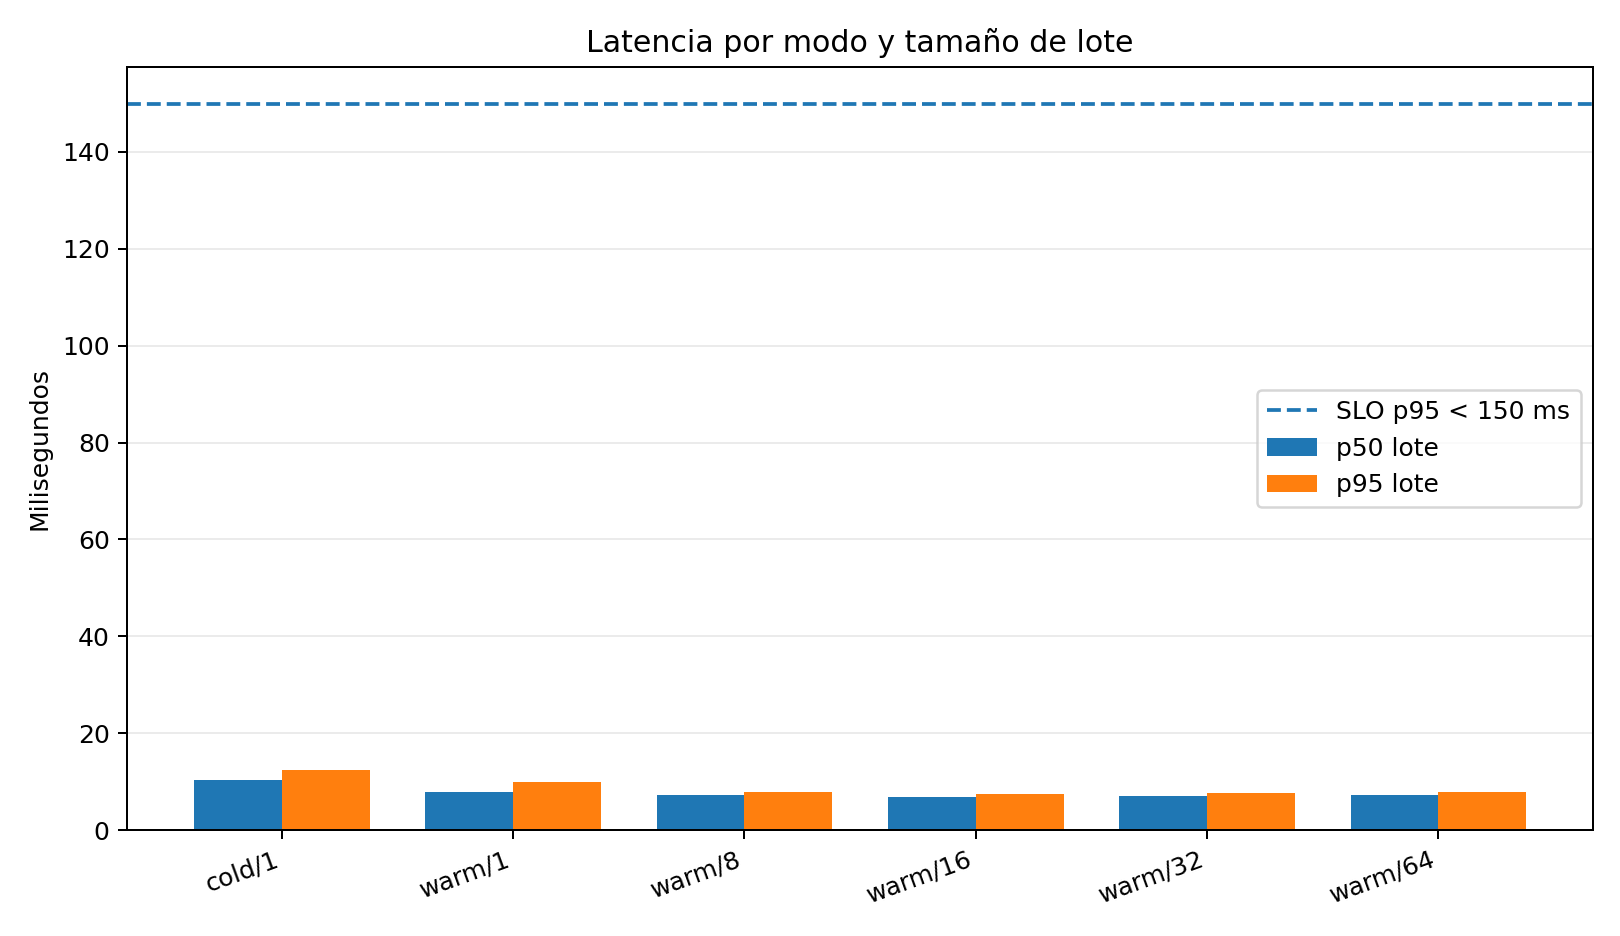

In [7]:
display(Image(filename=str(ROOT / 'results/fig_latency_p50_p95_sprint10.png')))

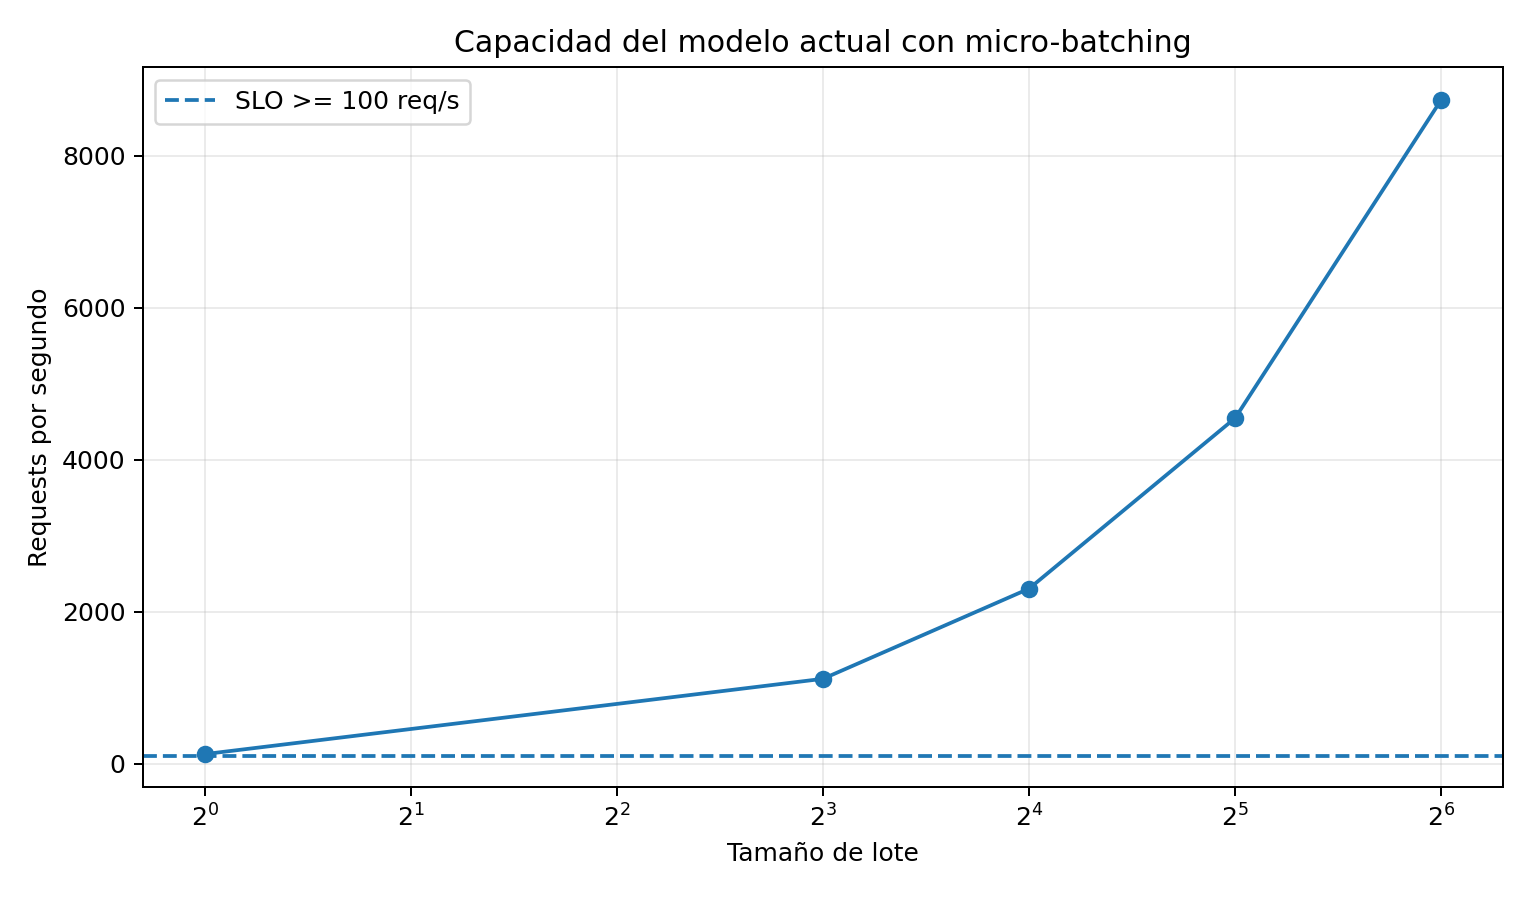

In [8]:
display(Image(filename=str(ROOT / 'results/fig_throughput_sprint10.png')))

## 4. Robustez y auditoría de fuga

In [9]:
robustness = pd.read_csv(ROOT / 'logs/invalid_input_tests_sprint10.csv')
leakage = pd.read_csv(ROOT / 'results/leakage_audit_sprint10.csv')
display(robustness)
display(leakage)
assert robustness['passed'].all()
assert robustness['internal_error'].sum() == 0

,case,expected,observed,passed,latency_ms,internal_error,message
0,valid_record,success,success,True,12.749115,0,NaN
1,missing_required_priority,validation_error,validation_error,True,0.476945,0,Faltan campos requeridos: priority
2,invalid_numeric_type,validation_error,validation_error,True,3.433049,0,El campo numérico 'hour' contiene un valor inv...
3,out_of_range_hour,validation_error,validation_error,True,4.898523,0,"'hour' fuera de rango [0, 23]: 25"
4,unknown_category,success,success,True,11.331262,0,NaN
5,extra_field,success,success,True,9.394291,0,NaN
6,null_category_as_missing,success,success,True,8.335077,0,NaN
7,empty_batch,validation_error,validation_error,True,0.010836,0,El lote no puede estar vacío.


,source,feature,leakage_type,reason,action,status
0,Sprint 8 artifact / HPO dataset,duration_hours_evidence,target leakage,label_over_ola se determina comparando duració...,"Excluir de entrenamiento, inferencia y selecci...",blocked
1,Sprint 7 clean dataset,sla_threshold_hours,allowed operational input,El umbral de SLA/OLA se conoce al abrir el cas...,Mantener como feature.,allowed
2,Sprint 7 clean dataset,label_source,metadata leakage risk,Describe cómo se construyó la etiqueta; no es ...,Excluir del contrato de inferencia.,blocked


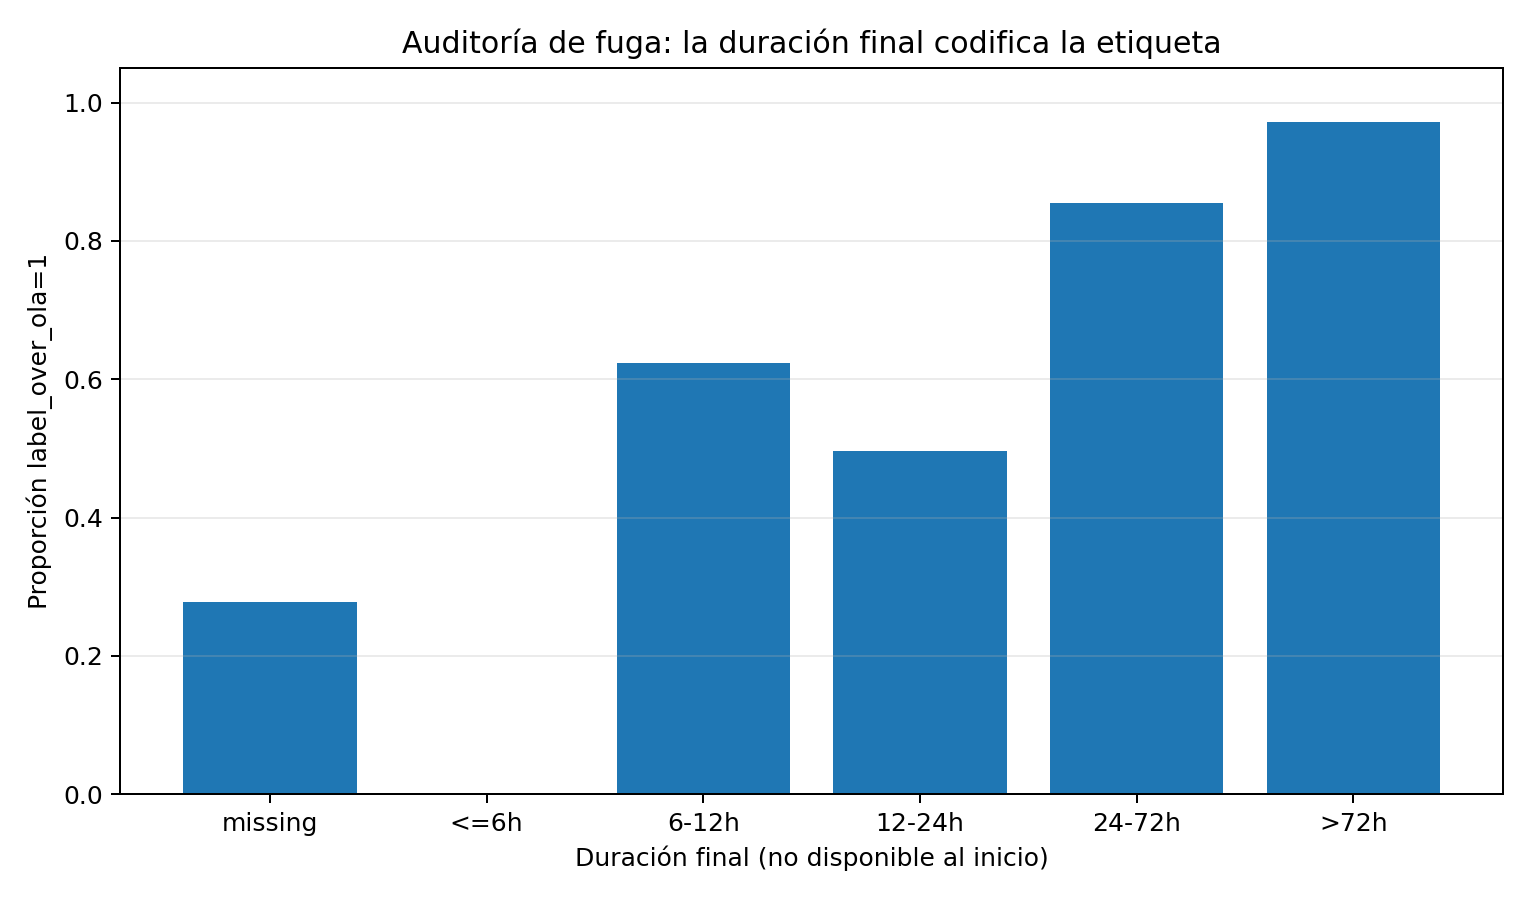

In [10]:
display(Image(filename=str(ROOT / 'results/fig_duration_target_leakage_sprint10.png')))

## 5. Percepción del stakeholder

In [11]:
status = pd.read_csv(ROOT / 'results/stakeholder_validation_status_sprint10.csv')
display(status)
print('La plantilla está en templates/stakeholder_responses_template_sprint10.csv')
print('Agregador: src/aggregate_stakeholder_feedback_sprint10.py')

,dimension,baseline,actual,status
0,utility_1_5,pending,pending,not_collected
1,clarity_1_5,pending,pending,not_collected
2,confidence_1_5,pending,pending,not_collected
3,task_success,pending,pending,not_collected
4,task_time_seconds,pending,pending,not_collected


La plantilla está en templates/stakeholder_responses_template_sprint10.csv
Agregador: src/aggregate_stakeholder_feedback_sprint10.py


## Reproducción completa

```bash
python src/run_sprint10_validation_latency.py
python -m unittest discover -s tests -v
python src/run_stakeholder_scenarios_sprint10.py
```

La ejecución actual recomienda **shadow mode**. No se recomienda producción con impacto real hasta validar percepción y acordar explícitamente el costo de falsos negativos frente a falsos positivos.